# gridT vs. Stan: inverse reconstruction comparison

**DRAFT / unreviewed** — this notebook lives on `claude/gridT-gui-exploratory` and exists to do the one thing that branch's `predict_grid.py` explicitly flags as missing: exercise `TEXAS.predict_grid.predict_T_grid()` end-to-end against a real cached forward posterior and compare it directly to `TEXAS.predict_T_from_proxyObs()` (the Stan/HMC path). See `README.md` on this branch and the module docstring in `src/TEXAS/predict_grid.py` for full context — do not treat either as production-validated until this notebook has actually been run and the numbers checked.

**Not executed here.** This container has no CmdStan install and no cached forward posterior (`data/cache/` is gitignored and machine-local, per `CLAUDE.md`), so `predict_T_from_proxyObs` cannot run in this environment — only `predict_T_grid`'s core quadrature math has been validated standalone (see `tests/test_predict_grid.py`). Run this notebook top-to-bottom on a machine with CmdStan installed (`TEXAS.install_cmdstan()`) and a forward posterior available (bundled, downloaded via `TEXAS.download_posteriors()`, or one you fit yourself).

What this notebook checks:
1. Both methods against the same forward posterior, same proxy observations, same prior.
2. Percentile-by-percentile agreement (p1 through p99 — the full set `predict_T_from_proxyObs` returns).
3. Where they diverge — expected to be the warm/saturated tail per `TEXAS-revision/gridT_inversion_characterization.md`, and anywhere `grid_truncated` is flagged.
4. Wall-clock time — the entire point of `predict_T_grid` is to be fast without CmdStan.

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import TEXAS
from TEXAS import predict_T_from_proxyObs
from TEXAS.predict_grid import predict_T_grid

PERCENTILES = [1, 5, 10, 16, 25, 50, 75, 84, 90, 95, 99]  # full set predict_T_from_proxyObs returns

/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/plotting/residual_maps.py:57: UserWarning: `natural_earth_v5_0_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` instead. See https://github.com/regionmask/regionmask/issues/410.
  _OCEAN_BASINS_50 = regionmask.defined_regions.natural_earth_v5_0_0.ocean_basins_50


## 1. Pick the forward posterior

Use the **same** `fwd_posterior` for both calls — that's the whole point of a fair comparison. The default multivariate T0-shift calibration ships with the package and needs no download; swap in any other case id you have cached.

In [2]:
FWD_POSTERIOR = "tx.GHEB.sst.sri03.G23-N1p0"  # bundled multivariate T0-shift calibration

# If you'd rather compare against the univariate model (no GDGT23/NO3 terms --
# simpler, and closer to the embedded posterior TEXAS-revision/gridT_inversion_characterization.md
# validates predict_T_grid's core math against), use this instead and drop the
# gdgt23ratio/no3 columns from the synthetic data below:
# FWD_POSTERIOR = "tx.GHPU.sst.sri03.p0"

## 2. Example proxy observations

A spread spanning cold, mid-curve, and warm/saturated proxy values — the last two are the interesting cases, since that's where `predict_T_grid`'s adaptive grid bound is expected to *disagree* with a hardcoded-cap version and (per the characterization doc) should track the real Stan posterior more closely, not less. Replace with your own downcore/coretop data.

In [15]:
proxyObs = np.array([0.45, 0.55, 0.65, 0.75, 0.85, 0.90, 0.94, 0.97])
prior_mu_t = 15.0
prior_sigma_t = 30.0

# Non-thermal predictors -- only used if FWD_POSTERIOR is a multivariate model.
# Set to 0 / a value above no3_cutoff to effectively disable each correction.
gdgt23ratio = np.full_like(proxyObs, 5)
no3 = np.full_like(proxyObs, 10.0)  # above the typical ~1.0 cutoff -> correction off

## 3. Run both methods

In [16]:
t0 = time.time()
result_stan = predict_T_from_proxyObs(
    proxyObs=proxyObs,
    prior_mu_t=prior_mu_t,
    prior_sigma_t=prior_sigma_t,
    fwd_posterior=FWD_POSTERIOR,
    temptype="SST",
    gdgt23ratio=gdgt23ratio,
    no3=no3,
    flags=False,  # quality flags aren't needed for this comparison
)
stan_seconds = time.time() - t0
print(f"Stan (HMC):  {stan_seconds:.1f} s")

/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]
/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
15:36:27 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan to exe file /home/rrattan/.texas/stan_cache/invT_g

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=8
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
   (build dir: /home/rrattan/.texas/stan_cache)


15:36:35 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift
15:36:35 - cmdstanpy - INFO - CmdStan start processing


✅ Compiled: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
Starting Stan sampling with 8 observations...


chain 1:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

15:36:45 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully
Stan (HMC):  18.8 s


In [17]:
t0 = time.time()
result_grid = predict_T_grid(
    proxyObs=proxyObs,
    prior_mu_t=prior_mu_t,
    prior_sigma_t=prior_sigma_t,
    fwd_posterior=FWD_POSTERIOR,
    gdgt23ratio=gdgt23ratio,
    no3=no3,
    percentiles=PERCENTILES,
)
grid_seconds = time.time() - t0
print(f"gridT (quadrature):  {grid_seconds:.3f} s")
print(f"speedup: {stan_seconds / grid_seconds:.0f}x")

⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/data/builder.py:211: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  total_available = post.dims[draw_dim_name]


gridT (quadrature):  0.501 s
speedup: 37x


## 4. Side-by-side comparison table

In [18]:
rows = []
for i, ri in enumerate(proxyObs):
    row = {"proxyObs": ri}
    for p in PERCENTILES:
        key = f"p{p}"
        row[f"stan_{key}"] = np.asarray(result_stan[key]).ravel()[i]
        row[f"grid_{key}"] = result_grid[key][i]
        row[f"diff_{key}"] = row[f"grid_{key}"] - row[f"stan_{key}"]
    row["grid_truncated"] = bool(result_grid["flags"]["grid_truncated"][i])
    rows.append(row)

df = pd.DataFrame(rows)
pd.set_option("display.width", 160)

# Focus view: median + 90% CI, and how far gridT is from Stan on each
df[["proxyObs", "stan_p5", "grid_p5", "stan_p50", "grid_p50", "diff_p50",
    "stan_p95", "grid_p95", "diff_p95", "grid_truncated"]]

,proxyObs,stan_p5,grid_p5,stan_p50,grid_p50,diff_p50,stan_p95,grid_p95,diff_p95,grid_truncated
0,0.45,-41.884065,-1.172999,-6.00768,4.423088,10.430768,10.155335,12.998438,2.843103,False
1,0.55,5.222834,5.547451,15.71210,15.715428,0.003328,21.687490,21.862874,0.175384,False
2,0.65,19.290490,19.636992,24.51160,24.562869,0.051269,28.423755,28.350846,-0.072909,False
3,0.75,26.732090,26.831641,30.30315,30.252909,-0.050241,33.385765,33.396020,0.010255,False
4,0.85,31.970830,32.068331,35.21785,35.238717,0.020867,39.142400,39.269068,0.126668,False
5,0.90,34.599095,34.664184,38.66540,38.577963,-0.087437,57.551325,55.909654,-1.641671,False
6,0.94,37.421355,37.237220,44.41525,44.490942,0.075692,78.669095,76.972980,-1.696115,False
7,0.97,39.362795,39.464967,50.61990,50.782419,0.162519,82.091815,82.831709,0.739894,False


In [19]:
print("max |diff| per percentile across all proxyObs values:")
for p in PERCENTILES:
    max_abs_diff = df[f"diff_p{p}"].abs().max()
    print(f"  p{p:>2}: {max_abs_diff:.3f} degC")

max |diff| per percentile across all proxyObs values:
  p 1: 58.262 degC
  p 5: 40.711 degC
  p10: 31.732 degC
  p16: 25.454 degC
  p25: 19.170 degC
  p50: 10.431 degC
  p75: 5.862 degC
  p84: 4.706 degC
  p90: 3.781 degC
  p95: 2.843 degC
  p99: 4.089 degC


## 5. Plots

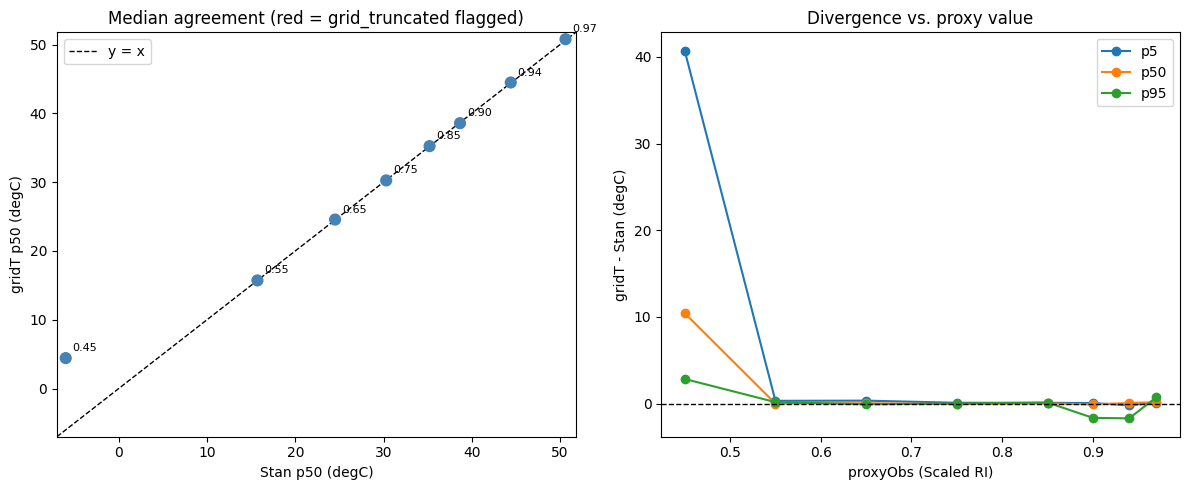

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) p50 agreement: Stan vs gridT, should sit on the y=x line
ax = axes[0]
lims = [
    min(df["stan_p50"].min(), df["grid_p50"].min()) - 1,
    max(df["stan_p50"].max(), df["grid_p50"].max()) + 1,
]
ax.plot(lims, lims, "k--", lw=1, label="y = x")
colors = ["crimson" if t else "steelblue" for t in df["grid_truncated"]]
ax.scatter(df["stan_p50"], df["grid_p50"], c=colors, s=60, zorder=3)
for _, r in df.iterrows():
    ax.annotate(f"{r.proxyObs:.2f}", (r.stan_p50, r.grid_p50),
                textcoords="offset points", xytext=(5, 5), fontsize=8)
ax.set_xlabel("Stan p50 (degC)")
ax.set_ylabel("gridT p50 (degC)")
ax.set_title("Median agreement (red = grid_truncated flagged)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend()

# (b) diff vs proxyObs, across percentiles -- where does disagreement concentrate?
ax = axes[1]
for p in (5, 50, 95):
    ax.plot(df["proxyObs"], df[f"diff_p{p}"], marker="o", label=f"p{p}")
ax.axhline(0, color="k", lw=1, ls="--")
ax.set_xlabel("proxyObs (Scaled RI)")
ax.set_ylabel("gridT - Stan (degC)")
ax.set_title("Divergence vs. proxy value")
ax.legend()

fig.tight_layout()
fig.savefig("gridT_vs_stan_comparison.png", dpi=150)
plt.show()

## 6. What to look for

- **Cold/mid-curve proxy values** (roughly RI &lt;= 0.80): expect `diff_p50` within ~0.01-0.05 degC and the tails within ~0.1 degC — this is the range `TEXAS-revision/gridT_inversion_characterization.md` validated against the embedded reference posterior.
- **Warm/saturated values** (RI &gt;= 0.85, `grid_truncated` possibly True on either side): larger disagreement is *expected*, not necessarily a bug in either method -- gridT's adaptive upper bound is specifically meant to avoid the truncation a fixed-cap grid would introduce there, so it may sit *closer* to the true posterior than a naive grid would, but it should still be checked against Stan's HMC samples (the ground truth) here, not assumed correct.
- **Multivariate predictors**: if `FWD_POSTERIOR` is a T0-shift multivariate model and you set non-zero `gdgt23ratio`/`no3` above, this also exercises `predict_T_grid`'s predictor-shift branch (`use_gd`/`use_no3`) for the first time against a real posterior -- worth checking closely, since that logic was written to mirror `invT_..._t0shift.stan` by hand rather than reusing Stan's own code path.
- **Large, systematic disagreement anywhere** (not just the flagged warm tail) means something in `predict_T_grid`'s `build_invT_inputData()` wiring is wrong -- e.g. wrong parameter suffix picked, predictor gating logic differs from the Stan model, EIV handling not accounted for -- and it should not be trusted until that's root-caused. Do not merge this branch to `main` on the strength of this notebook alone; get a co-author to look at the actual divergence pattern above first, per this branch's `README.md` banner.